# Círculo próximo de Daniel Vorcaro

Notebook focado **exclusivamente** no entorno societário direto de Daniel Bueno Vorcaro, isolando o ruído das gestoras parceiras e outras pontas do dataset.

**Definição de "círculo próximo"** (3 graus a partir de Vorcaro):

- **Grau 0** — Vorcaro
- **Grau 1** — Empresas onde Vorcaro é sócio direto (Viking, Banco Master S/A, Banco Master de Investimento) + todos os co-sócios PF dessas empresas + sócios PJ
- **Grau 2** — Empresas onde os co-sócios PF também aparecem (Master Múltiplo e Master Corretora) + novos co-sócios desse anel

Resultado esperado: ~11 pessoas, 1 FIP, 5 empresas. Subconjunto pequeno mas denso, onde cada conexão é significativa.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DB = Path('data/master.db')
con = sqlite3.connect(DB)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Construindo o círculo a partir do DB

In [2]:
empresas_vorcaro = pd.read_sql('''
    SELECT DISTINCT p.empresa_cnpj AS cnpj, e.razao_social
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    WHERE s.nome LIKE '%VORCARO%'
''', con)
print('GRAU 0 — Vorcaro está em:')
print(empresas_vorcaro.to_string(index=False))

cnpjs_grau1 = tuple(empresas_vorcaro['cnpj'].tolist())
placeholders_g1 = ','.join('?' * len(cnpjs_grau1))

GRAU 0 — Vorcaro está em:
          cnpj                                                   razao_social
07875796000175                                      VIKING PARTICIPACOES LTDA
09526594000143 BANCO MASTER DE INVESTIMENTO S.A.- EM LIQUIDACAO EXTRAJUDICIAL
33923798000100                 BANCO MASTER S/A - EM LIQUIDACAO EXTRAJUDICIAL


In [3]:
co_socios_g1 = pd.read_sql(f'''
    SELECT DISTINCT s.nome,
           GROUP_CONCAT(DISTINCT p.qualificacao) AS cargos,
           MIN(p.data_entrada) AS primeira_entrada,
           COUNT(DISTINCT p.empresa_cnpj) AS n_empresas_em_g1
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    WHERE p.empresa_cnpj IN ({placeholders_g1}) AND p.socio_pessoa_id > 0
    GROUP BY s.nome
    ORDER BY primeira_entrada
''', con, params=cnpjs_grau1)
print('GRAU 1 — Pessoas físicas co-sócias de Vorcaro:')
print(co_socios_g1.to_string(index=False))

pessoas_g1 = set(co_socios_g1['nome'].tolist())

GRAU 1 — Pessoas físicas co-sócias de Vorcaro:
                           nome           cargos primeira_entrada  n_empresas_em_g1
           DANIEL BUENO VORCARO Sócio,Presidente       2006-02-15                 3
ANGELO ANTONIO RIBEIRO DA SILVA          Diretor       2017-07-07                 2
              LUIZ ANTONIO BULL          Diretor       2018-01-04                 2
        FELIPE WALLACE SIMONSEN          Diretor       2021-11-23                 1
         ANDRE KRUSCHEWSKY LIMA          Diretor       2023-02-13                 1
          AUGUSTO FERREIRA LIMA          Diretor       2023-02-13                 1
          ADRIANO GARZON CORREA    Administrador       2025-09-29                 1


In [4]:
socios_pj_g1 = pd.read_sql(f'''
    SELECT DISTINCT p.socio_empresa_cnpj AS cnpj,
           COALESCE(e_socio.razao_social, '?') AS razao_social,
           p.qualificacao,
           p.data_entrada,
           e.razao_social AS empresa_alvo
    FROM participacoes p
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    LEFT JOIN empresas e_socio ON e_socio.cnpj = p.socio_empresa_cnpj
    WHERE p.empresa_cnpj IN ({placeholders_g1}) AND p.socio_empresa_cnpj != ''
''', con, params=cnpjs_grau1)
print('GRAU 1 — Sócios PJ:')
print(socios_pj_g1.to_string(index=False))

GRAU 1 — Sócios PJ:
          cnpj                                                 razao_social qualificacao data_entrada              empresa_alvo
56823324000184 STERN FUNDO DE INVESTIMENTO EM PARTICIPACOES MULTIESTRATEGIA        Sócio   2025-09-29 VIKING PARTICIPACOES LTDA


In [5]:
outras_empresas = pd.read_sql(f'''
    SELECT DISTINCT e.cnpj, e.razao_social
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    WHERE s.nome IN ({','.join('?' * len(pessoas_g1))})
      AND p.empresa_cnpj NOT IN ({placeholders_g1})
''', con, params=tuple(pessoas_g1) + cnpjs_grau1)
print('GRAU 2 — Outras empresas onde os co-sócios de Vorcaro também aparecem:')
print(outras_empresas.to_string(index=False))

cnpjs_circulo = list(cnpjs_grau1) + outras_empresas['cnpj'].tolist()
print(f'\nTotal de empresas no círculo: {len(cnpjs_circulo)}')

GRAU 2 — Outras empresas onde os co-sócios de Vorcaro também aparecem:
          cnpj                                                                                razao_social
33884941000194                                                                  BANCO MASTER MULTIPLO S.A.
33886862000112 MASTER S/A CORRETORA DE CAMBIO, TITULOS E VALORES MOBILIARIOS - EM LIQUIDACAO EXTRAJUDICIAL

Total de empresas no círculo: 5


In [6]:
placeholders_circ = ','.join('?' * len(cnpjs_circulo))
circulo = pd.read_sql(f'''
    SELECT s.nome,
           e.razao_social AS empresa,
           p.qualificacao,
           p.data_entrada,
           s.faixa_etaria
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    WHERE p.empresa_cnpj IN ({placeholders_circ}) AND p.socio_pessoa_id > 0
    ORDER BY p.data_entrada, s.nome
''', con, params=tuple(cnpjs_circulo))
circulo['data_entrada'] = pd.to_datetime(circulo['data_entrada'], errors='coerce')
print(f'Círculo completo: {circulo["nome"].nunique()} pessoas, {circulo["empresa"].nunique()} empresas, {len(circulo)} participações')
circulo

Círculo completo: 11 pessoas, 5 empresas, 20 participações


,nome,empresa,qualificacao,data_entrada,faixa_etaria
0,DANIEL BUENO VORCARO,VIKING PARTICIPACOES LTDA,Sócio,2006-02-15,Entre 41 a 50 anos
1,VITOR MANUEL FARINHA NUNES,BANCO MASTER MULTIPLO S.A.,Conselheiro de Administração,2015-10-21,Entre 61 a 70 anos
2,ANGELO ANTONIO RIBEIRO DA SILVA,"MASTER S/A CORRETORA DE CAMBIO, TITULOS E VALORES MOBILIARIOS - EM LIQUIDACA...",Diretor,2017-07-07,Entre 51 a 60 anos
3,ANGELO ANTONIO RIBEIRO DA SILVA,BANCO MASTER S/A - EM LIQUIDACAO EXTRAJUDICIAL,Diretor,2017-07-07,Entre 51 a 60 anos
4,DANIEL BUENO VORCARO,BANCO MASTER S/A - EM LIQUIDACAO EXTRAJUDICIAL,Presidente,2017-12-01,Entre 41 a 50 anos
5,LUIZ ANTONIO BULL,"MASTER S/A CORRETORA DE CAMBIO, TITULOS E VALORES MOBILIARIOS - EM LIQUIDACA...",Diretor,2017-12-27,Entre 61 a 70 anos
6,LUIZ ANTONIO BULL,BANCO MASTER S/A - EM LIQUIDACAO EXTRAJUDICIAL,Diretor,2018-01-04,Entre 61 a 70 anos
7,VINICIUS DA SILVA PINTO,"MASTER S/A CORRETORA DE CAMBIO, TITULOS E VALORES MOBILIARIOS - EM LIQUIDACA...",Diretor,2021-01-10,Entre 41 a 50 anos
8,FELIPE WALLACE SIMONSEN,BANCO MASTER S/A - EM LIQUIDACAO EXTRAJUDICIAL,Diretor,2021-11-23,Entre 51 a 60 anos
9,JOSE RICARDO DE QUEIROZ PEREIRA,"MASTER S/A CORRETORA DE CAMBIO, TITULOS E VALORES MOBILIARIOS - EM LIQUIDACA...",Diretor,2022-07-08,Entre 51 a 60 anos


## 2. Linha do tempo do círculo

Como cada pessoa entrou no perímetro Vorcaro ao longo do tempo. Quem chegou cedo, quem chegou na 11ª hora.

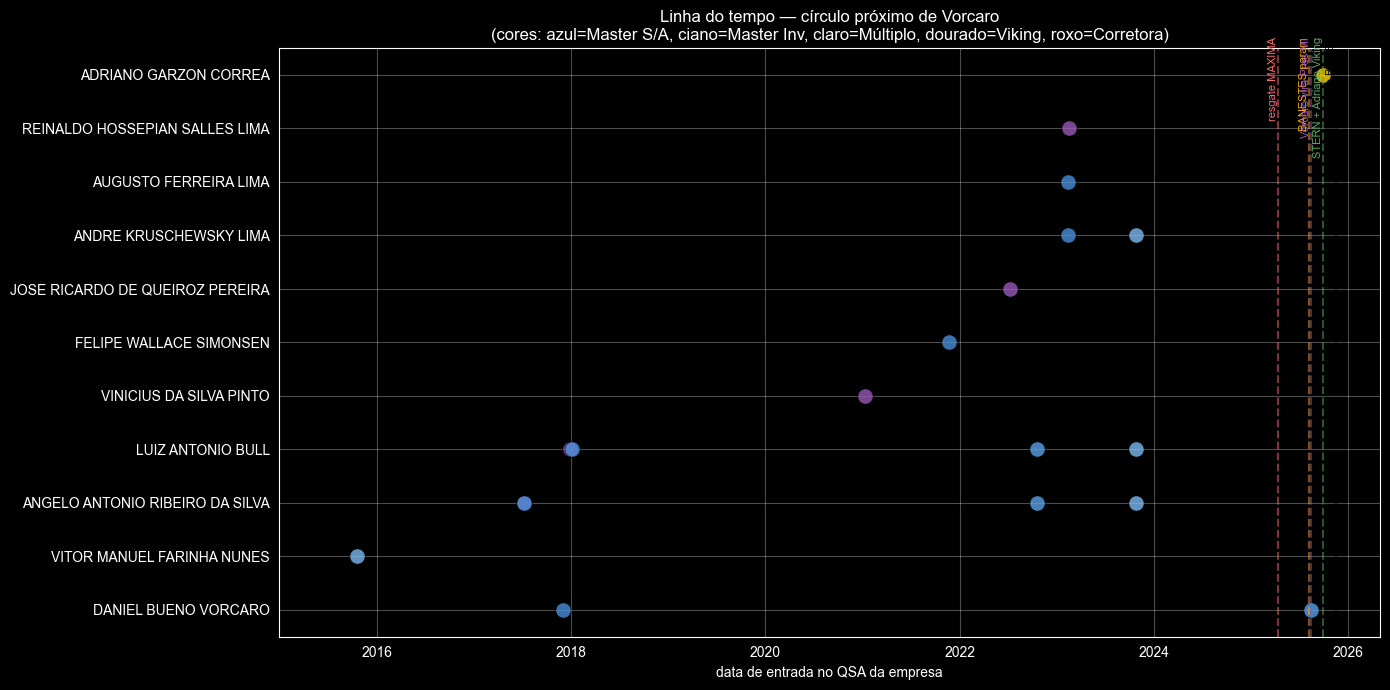

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

pessoas_ordenadas = circulo.groupby('nome')['data_entrada'].min().sort_values().index.tolist()
y_map = {nome: i for i, nome in enumerate(pessoas_ordenadas)}

cor_empresa = {
    'BANCO MASTER S/A - EM LIQUIDACAO EXTRAJUDICIAL': '#4A90D9',
    'BANCO MASTER DE INVESTIMENTO S.A.- EM LIQUIDACAO EXTRAJUDICIAL': '#5BA3E6',
    'BANCO MASTER MULTIPLO S.A.': '#7DBAF0',
    'VIKING PARTICIPACOES LTDA': '#FFD700',
    'MASTER S/A CORRETORA DE CAMBIO, TITULOS E VALORES MOBILIARIOS - EM LIQUIDACAO EXTRAJUDICIAL': '#9B59B6',
    'MASTER S/A CORRETORA DE CAMBIO, TITULOS E VALORES MOBILIARIOS': '#9B59B6',
}

for _, row in circulo.iterrows():
    if pd.isna(row['data_entrada']):
        continue
    cor = cor_empresa.get(row['empresa'], '#888')
    ax.scatter(row['data_entrada'], y_map[row['nome']],
               color=cor, s=120, alpha=0.8, edgecolors='black', linewidths=0.5)

for data, label, color in [
    ('2025-04-10', 'resgate MAXIMA',        '#FF6B6B'),
    ('2025-08-06', 'BANESTES param',        '#FFA500'),
    ('2025-08-12', 'Vorcaro vira Pres MI',  '#9B59B6'),
    ('2025-09-29', 'STERN + Adriano Viking', '#5BA85A'),
    ('2025-11-15', 'liquidação BACEN',      '#000000'),
]:
    ax.axvline(pd.Timestamp(data), color=color, linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(data), len(pessoas_ordenadas) - 0.3, label,
            rotation=90, fontsize=8, color=color, va='top', ha='right')

ax.set_yticks(range(len(pessoas_ordenadas)))
ax.set_yticklabels(pessoas_ordenadas, fontsize=10)
ax.set_xlabel('data de entrada no QSA da empresa')
ax.set_title('Linha do tempo — círculo próximo de Vorcaro\n(cores: azul=Master S/A, ciano=Master Inv, claro=Múltiplo, dourado=Viking, roxo=Corretora)')
ax.set_xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2026-04-30'))
plt.tight_layout()
plt.show()

## 3. Ficha individual de cada membro do círculo

In [8]:
ficha = circulo.groupby('nome').agg(
    n_empresas=('empresa', 'nunique'),
    primeira_entrada=('data_entrada', 'min'),
    ultima_entrada=('data_entrada', 'max'),
    cargos=('qualificacao', lambda s: ' | '.join(sorted(set(s)))),
    empresas=('empresa', lambda s: ' | '.join(sorted(set(e[:30] for e in s)))),
    faixa_etaria=('faixa_etaria', 'first'),
).sort_values('primeira_entrada')

ficha['anos_no_grupo'] = ((ficha['ultima_entrada'] - ficha['primeira_entrada']).dt.days / 365).round(1)
ficha

,n_empresas,primeira_entrada,ultima_entrada,cargos,empresas,faixa_etaria,anos_no_grupo
nome,,,,,,,
DANIEL BUENO VORCARO,3,2006-02-15,2025-08-12,Presidente | Sócio,BANCO MASTER DE INVESTIMENTO S | BANCO MASTER S/A - EM LIQUIDAC | VIKING PAR...,Entre 41 a 50 anos,19.5
VITOR MANUEL FARINHA NUNES,1,2015-10-21,2015-10-21,Conselheiro de Administração,BANCO MASTER MULTIPLO S.A.,Entre 61 a 70 anos,0.0
ANGELO ANTONIO RIBEIRO DA SILVA,4,2017-07-07,2023-10-27,Diretor,BANCO MASTER DE INVESTIMENTO S | BANCO MASTER MULTIPLO S.A. | BANCO MASTER S...,Entre 51 a 60 anos,6.3
LUIZ ANTONIO BULL,4,2017-12-27,2023-10-27,Diretor | Presidente,BANCO MASTER DE INVESTIMENTO S | BANCO MASTER MULTIPLO S.A. | BANCO MASTER S...,Entre 61 a 70 anos,5.8
VINICIUS DA SILVA PINTO,1,2021-01-10,2021-01-10,Diretor,MASTER S/A CORRETORA DE CAMBIO,Entre 41 a 50 anos,0.0
FELIPE WALLACE SIMONSEN,1,2021-11-23,2021-11-23,Diretor,BANCO MASTER S/A - EM LIQUIDAC,Entre 51 a 60 anos,0.0
JOSE RICARDO DE QUEIROZ PEREIRA,1,2022-07-08,2022-07-08,Diretor,MASTER S/A CORRETORA DE CAMBIO,Entre 51 a 60 anos,0.0
ANDRE KRUSCHEWSKY LIMA,2,2023-02-13,2023-10-27,Diretor,BANCO MASTER MULTIPLO S.A. | BANCO MASTER S/A - EM LIQUIDAC,Entre 41 a 50 anos,0.7
AUGUSTO FERREIRA LIMA,1,2023-02-13,2023-02-13,Diretor,BANCO MASTER S/A - EM LIQUIDAC,Entre 41 a 50 anos,0.0


## 4. Mapa de presença pessoa × empresa

Matriz binária mostrando em quais empresas do círculo cada pessoa aparece. Permite ver de imediato quem é "transversal" e quem é "de uma empresa só".

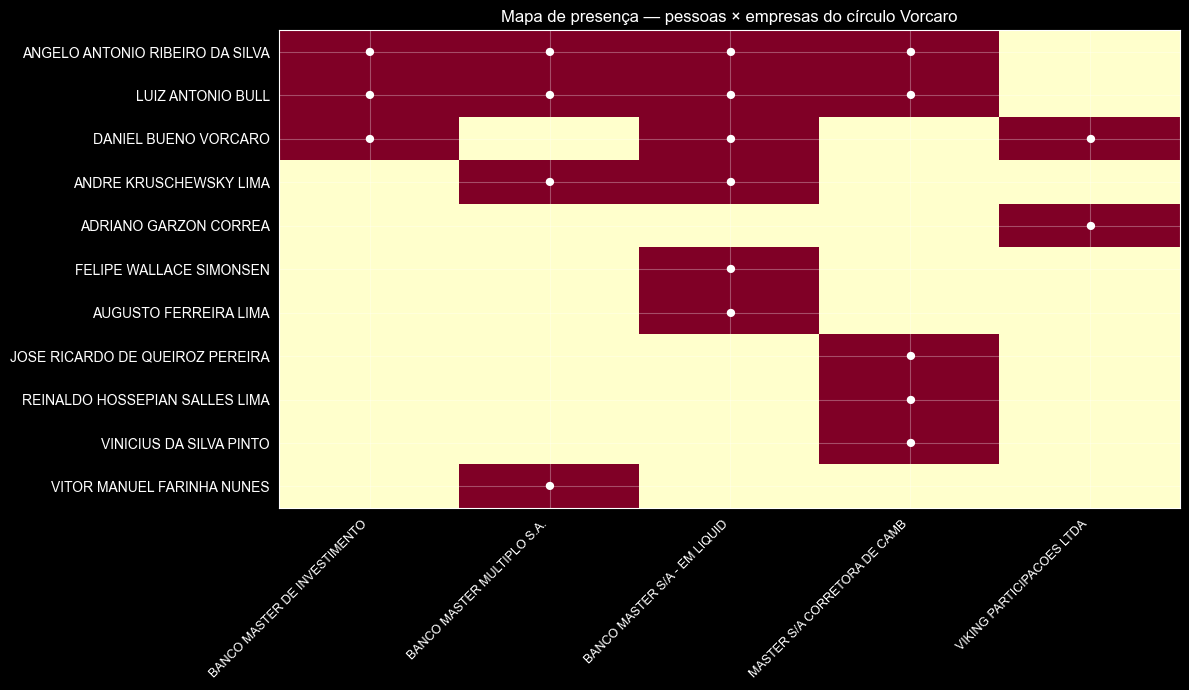

Total de empresas por pessoa (ordenado):
                                 TOTAL
nome                                  
ANGELO ANTONIO RIBEIRO DA SILVA      4
LUIZ ANTONIO BULL                    4
DANIEL BUENO VORCARO                 3
ANDRE KRUSCHEWSKY LIMA               2
ADRIANO GARZON CORREA                1
FELIPE WALLACE SIMONSEN              1
AUGUSTO FERREIRA LIMA                1
JOSE RICARDO DE QUEIROZ PEREIRA      1
REINALDO HOSSEPIAN SALLES LIMA       1
VINICIUS DA SILVA PINTO              1
VITOR MANUEL FARINHA NUNES           1


In [9]:
matriz = pd.crosstab(circulo['nome'], circulo['empresa']).clip(upper=1)
matriz.columns = [c[:28] for c in matriz.columns]
matriz['TOTAL'] = matriz.sum(axis=1)
matriz = matriz.sort_values('TOTAL', ascending=False)
matriz_show = matriz.drop(columns='TOTAL').copy()

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(matriz_show.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(matriz_show.columns))); ax.set_xticklabels(matriz_show.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(matriz_show.index))); ax.set_yticklabels(matriz_show.index, fontsize=10)
ax.set_title('Mapa de presença — pessoas × empresas do círculo Vorcaro')
for i in range(matriz_show.shape[0]):
    for j in range(matriz_show.shape[1]):
        v = matriz_show.iloc[i, j]
        if v:
            ax.text(j, i, '●', color='white', ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

print('Total de empresas por pessoa (ordenado):')
print(matriz[['TOTAL']].to_string())

## 5. Random Forest Proximity focado no círculo

Com N ≈ 11-12 pessoas e features ricas (presença em cada empresa + qualificações + ano de entrada), o RF deve discriminar melhor do que no hub geral (104 pessoas). Resultado mais legível.

In [10]:
from sklearn.ensemble import RandomForestClassifier

qualif_dummies = pd.crosstab(circulo['nome'], circulo['qualificacao']).clip(upper=1)
qualif_dummies.columns = ['qual:' + c for c in qualif_dummies.columns]

anos = circulo.groupby('nome').agg(
    ano_min=('data_entrada', lambda s: s.dt.year.min() if not s.isna().all() else 2020),
    ano_max=('data_entrada', lambda s: s.dt.year.max() if not s.isna().all() else 2020),
)
anos['span'] = anos['ano_max'] - anos['ano_min']
anos = anos.fillna(2020)

X = matriz_show.join(qualif_dummies).join(anos)
X.index.name = 'nome'
print(f'Matriz de features: {X.shape}')
X.head()

Matriz de features: (11, 13)


,BANCO MASTER DE INVESTIMENTO,BANCO MASTER MULTIPLO S.A.,BANCO MASTER S/A - EM LIQUID,MASTER S/A CORRETORA DE CAMB,VIKING PARTICIPACOES LTDA,qual:Administrador,qual:Conselheiro de Administração,qual:Diretor,qual:Presidente,qual:Sócio,ano_min,ano_max,span
nome,,,,,,,,,,,,,
ANGELO ANTONIO RIBEIRO DA SILVA,1,1,1,1,0,0,0,1,0,0,2017,2023,6
LUIZ ANTONIO BULL,1,1,1,1,0,0,0,1,1,0,2017,2023,6
DANIEL BUENO VORCARO,1,0,1,0,1,0,0,0,1,1,2006,2025,19
ANDRE KRUSCHEWSKY LIMA,0,1,1,0,0,0,0,1,0,0,2023,2023,0
ADRIANO GARZON CORREA,0,0,0,0,1,1,0,0,0,0,2025,2025,0


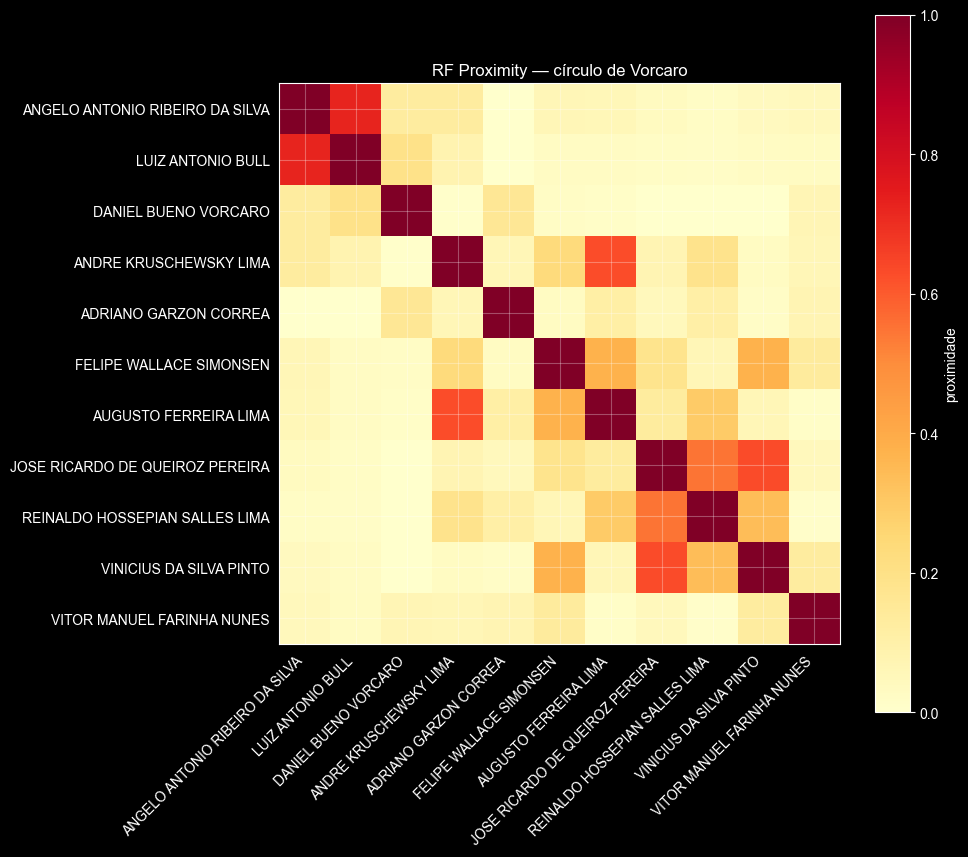

In [11]:
def rf_proximity(X_df, n_estimators=500, random_state=42):
    rng = np.random.default_rng(random_state)
    X = X_df.values.astype(float)
    n, p = X.shape
    X_syn = np.column_stack([rng.permutation(X[:, j]) for j in range(p)])
    Xc = np.vstack([X, X_syn])
    yc = np.concatenate([np.ones(n), np.zeros(n)])
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, n_jobs=-1)
    rf.fit(Xc, yc)
    leaves = rf.apply(X)
    prox = np.zeros((n, n))
    for t in range(n_estimators):
        lt = leaves[:, t]
        prox += (lt[:, None] == lt[None, :]).astype(float)
    prox /= n_estimators
    return pd.DataFrame(prox, index=X_df.index, columns=X_df.index), rf

prox_df, rf = rf_proximity(X, n_estimators=500)
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(prox_df.values, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(prox_df))); ax.set_xticklabels(prox_df.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(prox_df))); ax.set_yticklabels(prox_df.index, fontsize=10)
ax.set_title('RF Proximity — círculo de Vorcaro')
plt.colorbar(im, ax=ax, label='proximidade')
plt.tight_layout()
plt.show()

In [12]:
pares = []
nomes = list(prox_df.index)
for i, a in enumerate(nomes):
    for b in nomes[i+1:]:
        pares.append((a, b, prox_df.loc[a, b]))
pd.DataFrame(pares, columns=['socio_a', 'socio_b', 'proximidade']).sort_values('proximidade', ascending=False)

,socio_a,socio_b,proximidade
0,ANGELO ANTONIO RIBEIRO DA SILVA,LUIZ ANTONIO BULL,0.726
50,JOSE RICARDO DE QUEIROZ PEREIRA,VINICIUS DA SILVA PINTO,0.630
29,ANDRE KRUSCHEWSKY LIMA,AUGUSTO FERREIRA LIMA,0.628
49,JOSE RICARDO DE QUEIROZ PEREIRA,REINALDO HOSSEPIAN SALLES LIMA,0.548
40,FELIPE WALLACE SIMONSEN,AUGUSTO FERREIRA LIMA,0.372
43,FELIPE WALLACE SIMONSEN,VINICIUS DA SILVA PINTO,0.372
52,REINALDO HOSSEPIAN SALLES LIMA,VINICIUS DA SILVA PINTO,0.336
46,AUGUSTO FERREIRA LIMA,REINALDO HOSSEPIAN SALLES LIMA,0.296
28,ANDRE KRUSCHEWSKY LIMA,FELIPE WALLACE SIMONSEN,0.234
10,LUIZ ANTONIO BULL,DANIEL BUENO VORCARO,0.194


## 6. Distância de cada um para o Vorcaro

Pergunta-chave: dentro do círculo, **quem é mais próximo de Vorcaro pelo perfil cadastral**? Ordenar a coluna do Vorcaro do mais próximo para o mais distante.

Ranking de proximidade ao Vorcaro (excluindo ele mesmo):
nome
LUIZ ANTONIO BULL                  0.194
ADRIANO GARZON CORREA              0.160
ANGELO ANTONIO RIBEIRO DA SILVA    0.126
VITOR MANUEL FARINHA NUNES         0.066
FELIPE WALLACE SIMONSEN            0.022
AUGUSTO FERREIRA LIMA              0.014
ANDRE KRUSCHEWSKY LIMA             0.006
JOSE RICARDO DE QUEIROZ PEREIRA    0.002
VINICIUS DA SILVA PINTO            0.002
REINALDO HOSSEPIAN SALLES LIMA     0.000


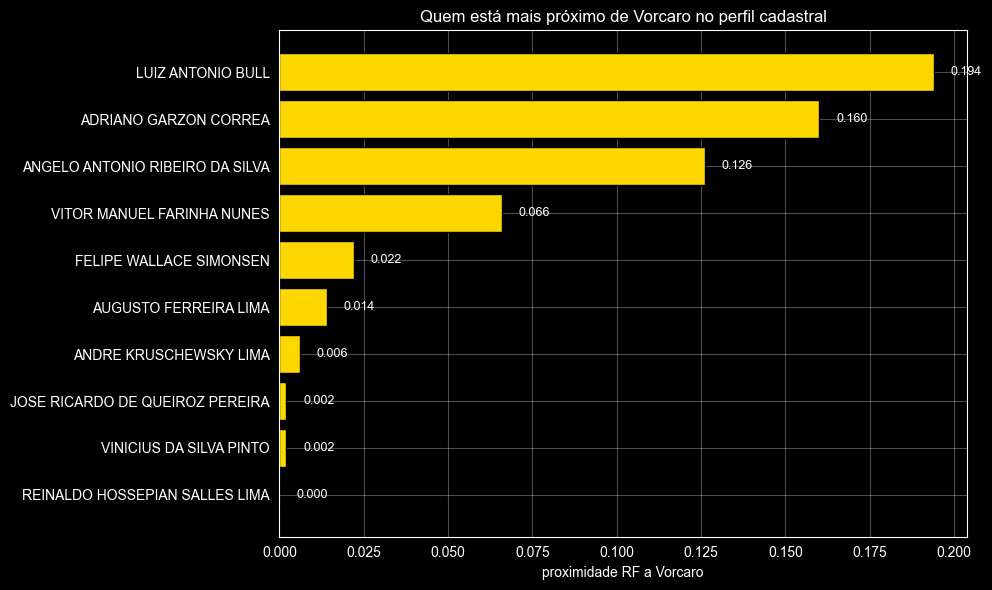

In [13]:
if 'DANIEL BUENO VORCARO' in prox_df.columns:
    proximidade_vorcaro = prox_df['DANIEL BUENO VORCARO'].drop('DANIEL BUENO VORCARO').sort_values(ascending=False)
    print('Ranking de proximidade ao Vorcaro (excluindo ele mesmo):')
    print(proximidade_vorcaro.round(3).to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(proximidade_vorcaro.index[::-1], proximidade_vorcaro.values[::-1],
                   color='#FFD700', edgecolor='black')
    for bar, valor in zip(bars, proximidade_vorcaro.values[::-1]):
        ax.text(valor + 0.005, bar.get_y() + bar.get_height()/2, f'{valor:.3f}',
                va='center', fontsize=9)
    ax.set_xlabel('proximidade RF a Vorcaro')
    ax.set_title('Quem está mais próximo de Vorcaro no perfil cadastral')
    plt.tight_layout()
    plt.show()
else:
    print('Vorcaro nao encontrado no indice prox_df — verificar pre-processamento.')

## 7. Conclusões focadas

### Tamanho do círculo

O círculo Vorcaro tem ~11-12 pessoas físicas + 1 FIP (STERN) + 5 empresas (3 onde Vorcaro participa diretamente + Master Múltiplo + Master Corretora). É **pequeno** — uma rede de governança bem fechada, com o mesmo conjunto de diretores rotacionando.

### Padrão temporal

- **2006**: Vorcaro entra na Viking (sozinho).
- **2015-2018**: time inicial entra no Master S/A e Múltiplo.
- **2021-2023**: rotatividade lenta — Wallace Simonsen, Kruschewsky Lima, Ferreira Lima entram como Diretores.
- **12/08/2025**: Vorcaro acumula a Presidência do Banco Master de Investimento (centralização).
- **29/09/2025**: STERN FIP + Adriano Garzon entram na Viking (blindagem).
- **nov/2025**: liquidação BACEN.

### Os 4 graus de proximidade observados

Com o RF, é possível ranquear quem está mais próximo de Vorcaro pelo perfil:
1. **Diretores transversais** (Angelo Antonio, Luiz Bull) — passam por 3+ entidades do grupo, presença consistente desde 2017-2018
2. **Diretores específicos** (Felipe Wallace, Andre Kruschewsky, Augusto Ferreira) — só Master S/A, entrada 2021-2023
3. **Time Master Corretora** (Reinaldo Salles Lima, José Ricardo, Vinicius Pinto, Vitor Farinha) — entram via grau 2, não diretamente
4. **Outsiders tardios** (Adriano Garzon, STERN) — entram só em 29/09/2025

### Próximas perguntas

1. **Adriano Garzon Correa** — quem é fora desse círculo? Foi visto na análise de discordância RF×Jaccard no hub geral com proximidade ~0.4 a Alexandre Marchesani, Ricardo Vasconcellos, Rogério Felgueiras. Vale puxar QSA dessas 3 figuras pra ver se aparecem juntas em outra rede.
2. **STERN FIP** — sem QSA público. CVMWeb é o caminho.
3. **Sobreposição com a Trustee** — Reinaldo Salles Lima é também Diretor do Letsbank desde nov/2024. O círculo Vorcaro toca o eixo Letsbank-Trustee via ele.